# Exploratory Data Analysis and Feature Selection

This notebook continues the reimplementation of the paper
"Multiclass Classification of Fetal Health using Cardiotocogram Data."

The cleaned dataset contains 2,113 observations, 21 input features, and a
three-class fetal health target.

In this notebook, the following steps are performed:

1. Exploratory analysis of the cleaned dataset
2. Analysis of class distribution
3. Correlation analysis
4. Feature scoring using SelectKBest
5. Selection of the 10 features reported in the paper
6. 70/30 train-test split
7. Feature standardization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Load the Cleaned Dataset

The cleaned dataset produced during the preprocessing stage is loaded for
exploratory analysis and feature selection.

In [2]:
FILE_PATH = "/content/fetal_health_cleaned.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2113, 22)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120,0.000,0.0,0.000,0.000,0.0,0.0,73,0.5,43,...,62,126,2,0,120,137,121,73,1,2
1,132,0.006,0.0,0.006,0.003,0.0,0.0,17,2.1,0,...,68,198,6,1,141,136,140,12,0,1
2,133,0.003,0.0,0.008,0.003,0.0,0.0,16,2.1,0,...,68,198,5,1,141,135,138,13,0,1
3,134,0.003,0.0,0.008,0.003,0.0,0.0,16,2.4,0,...,53,170,11,0,137,134,137,13,1,1
4,132,0.007,0.0,0.008,0.000,0.0,0.0,16,2.4,0,...,53,170,9,0,137,136,138,11,1,1


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
print(df["fetal_health"].value_counts().sort_index())

print("\nColumn names:")
print(df.columns.tolist())

Rows: 2113
Columns: 22

Missing values: 0
Duplicate rows: 0

Class distribution:
fetal_health
1    1646
2     292
3     175
Name: count, dtype: int64

Column names:
['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'mean_value_of_long_term_variability', 'histogram_width', 'histogram_min', 'histogram_max', 'histogram_number_of_peaks', 'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean', 'histogram_median', 'histogram_variance', 'histogram_tendency', 'fetal_health']


## Exploratory Data Analysis

The cleaned data is first explored to understand the distribution of the
target classes and relationships between the input features.

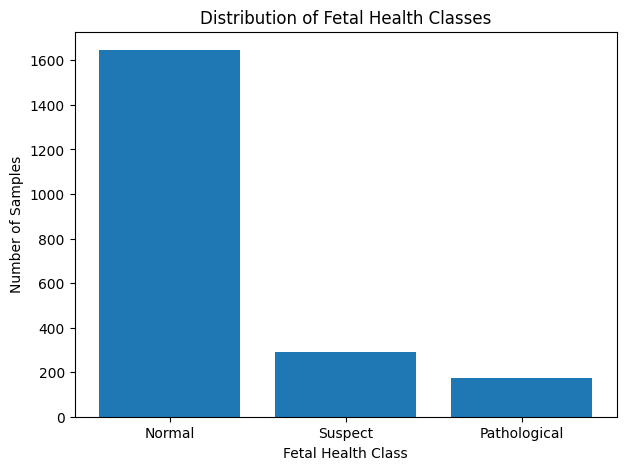

Normal: 1646
Suspect: 292
Pathological: 175


In [4]:
class_counts = (
    df["fetal_health"]
    .value_counts()
    .sort_index()
    .reindex([1, 2, 3])
)

class_names = ["Normal", "Suspect", "Pathological"]

plt.figure(figsize=(7, 5))

plt.bar(
    class_names,
    class_counts.values
)

plt.title("Distribution of Fetal Health Classes")
plt.xlabel("Fetal Health Class")
plt.ylabel("Number of Samples")

plt.show()

print("Normal:", class_counts.loc[1])
print("Suspect:", class_counts.loc[2])
print("Pathological:", class_counts.loc[3])

### Class Distribution

The dataset is imbalanced. The Normal class contains considerably more
observations than the Suspect and Pathological classes.

The final distribution is:

- Normal: 1,646 observations
- Suspect: 292 observations
- Pathological: 175 observations

In [5]:
X = df.drop(columns=["fetal_health"]).copy()
y = df["fetal_health"].astype(int).copy()

print("Feature matrix:", X.shape)
print("Target:", y.shape)

Feature matrix: (2113, 21)
Target: (2113,)


## Correlation Analysis

A correlation matrix is used to examine relationships between the 21
cardiotocography features.

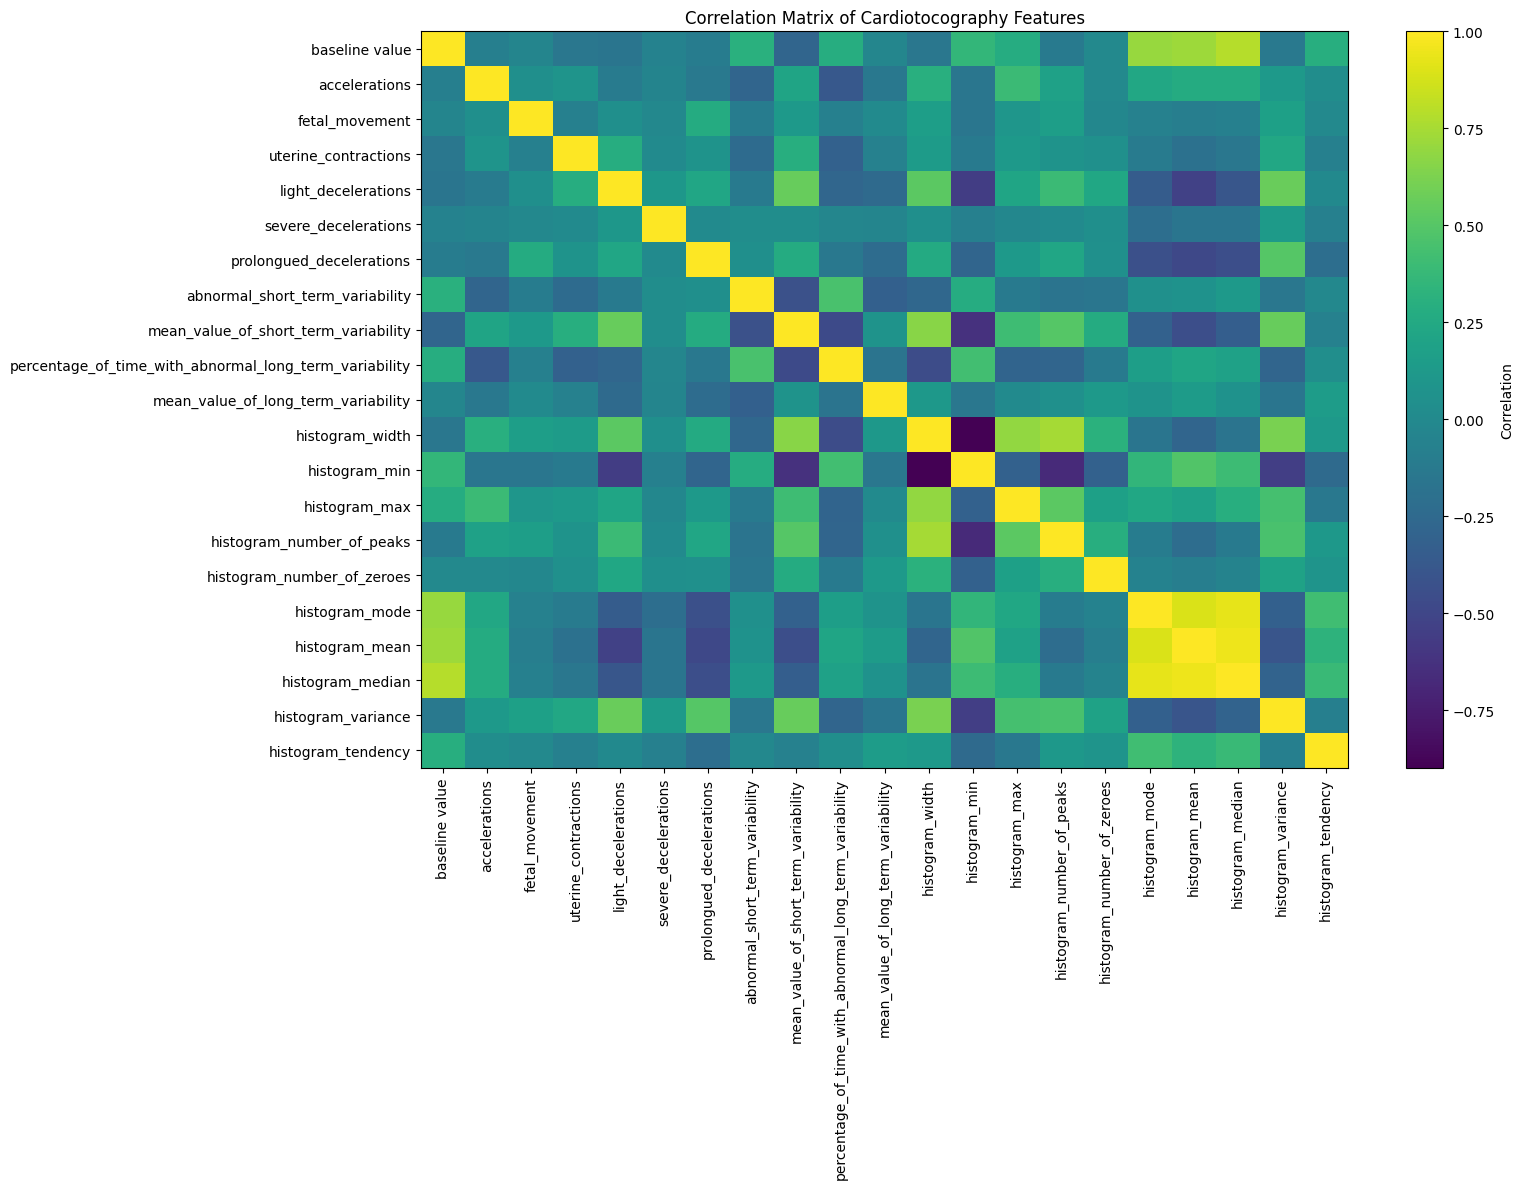

In [6]:
correlation_matrix = X.corr()

plt.figure(figsize=(16, 12))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Cardiotocography Features")

plt.tight_layout()
plt.show()

## Feature Selection using SelectKBest

The reference paper uses a KBest feature-selection method to score the
cardiotocography attributes and identify the most informative features for
fetal health classification.

ANOVA F-values are calculated using `f_classif` for each feature.

In [8]:
kbest_all = SelectKBest(
    score_func=f_classif,
    k="all"
)

kbest_all.fit(X, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": kbest_all.scores_
})

feature_scores = (
    feature_scores
    .sort_values("Score", ascending=False)
    .reset_index(drop=True)
)

feature_scores

,Feature,Score
0,prolongued_decelerations,507.304309
1,abnormal_short_term_variability,337.703020
2,percentage_of_time_with_abnormal_long_term_var...,335.386156
3,histogram_mean,298.759569
4,histogram_mode,276.382795
5,histogram_median,249.699523
6,accelerations,194.618345
7,histogram_variance,150.955827
8,baseline value,137.833999
9,mean_value_of_short_term_variability,118.050463


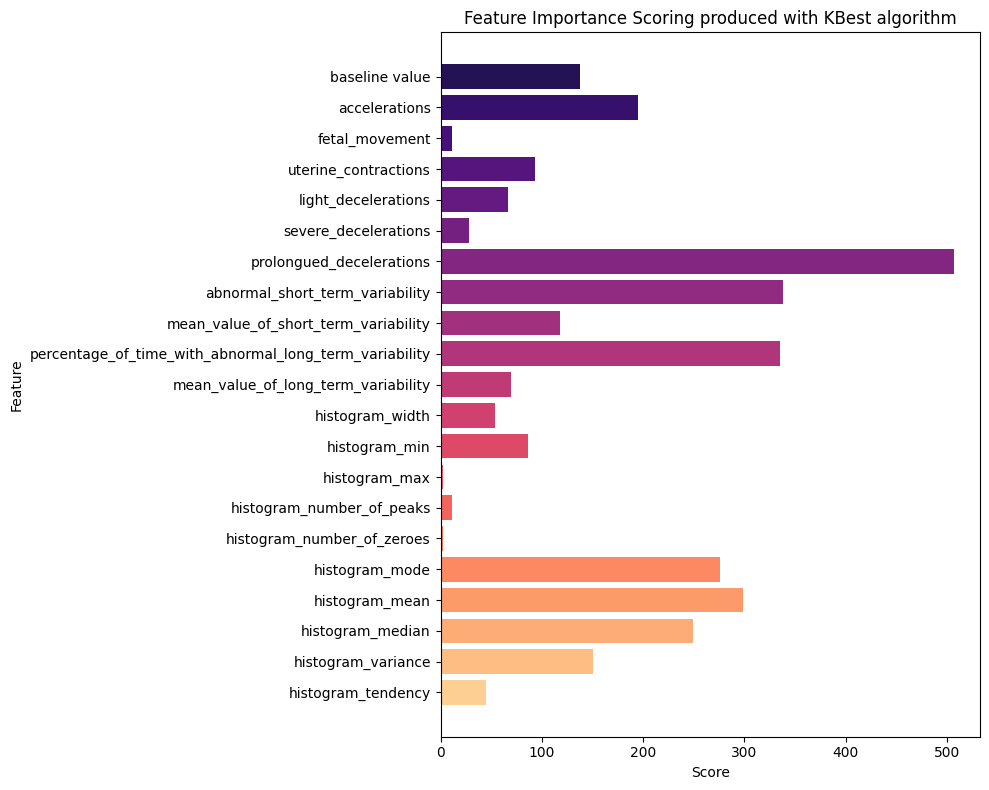

In [31]:
# Keep features in their ORIGINAL dataset order
feature_scores_original_order = pd.DataFrame({
    "Feature": X.columns,
    "Score": kbest_all.scores_
})

# Purple -> orange gradient similar to the paper
colors = plt.cm.magma(
    np.linspace(0.15, 0.90, len(feature_scores_original_order))
)

plt.figure(figsize=(10, 8))

plt.barh(
    feature_scores_original_order["Feature"],
    feature_scores_original_order["Score"],
    color=colors
)

plt.xlabel("Score")
plt.ylabel("Feature")
plt.title("Feature Importance Scoring produced with KBest algorithm")

# Match paper-style ordering: first feature at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [10]:
top10_computed = feature_scores.head(10)

print("Top 10 features obtained using SelectKBest:\n")
print(top10_computed.to_string(index=False))

Top 10 features obtained using SelectKBest:

                                               Feature      Score
                              prolongued_decelerations 507.304309
                       abnormal_short_term_variability 337.703020
percentage_of_time_with_abnormal_long_term_variability 335.386156
                                        histogram_mean 298.759569
                                        histogram_mode 276.382795
                                      histogram_median 249.699523
                                         accelerations 194.618345
                                    histogram_variance 150.955827
                                        baseline value 137.833999
                  mean_value_of_short_term_variability 118.050463


## Selected Features

The following 10 features were selected in the reference paper using
KBest feature scoring. These features are used for the subsequent model
training and evaluation.

In [11]:
selected_features = [
    "baseline value",
    "accelerations",
    "prolongued_decelerations",
    "abnormal_short_term_variability",
    "mean_value_of_short_term_variability",
    "percentage_of_time_with_abnormal_long_term_variability",
    "histogram_mode",
    "histogram_mean",
    "histogram_median",
    "histogram_variance"
]

print("Selected features:")

for i, feature in enumerate(selected_features, start=1):
    print(f"{i}. {feature}")

Selected features:
1. baseline value
2. accelerations
3. prolongued_decelerations
4. abnormal_short_term_variability
5. mean_value_of_short_term_variability
6. percentage_of_time_with_abnormal_long_term_variability
7. histogram_mode
8. histogram_mean
9. histogram_median
10. histogram_variance


In [12]:
missing_features = [
    feature
    for feature in selected_features
    if feature not in X.columns
]

if len(missing_features) == 0:
    print("All 10 selected features are present.")
else:
    print("Missing features:")
    print(missing_features)

All 10 selected features are present.


In [13]:
X_selected = X[selected_features].copy()

print("Selected dataset shape:", X_selected.shape)

X_selected.head()

Selected dataset shape: (2113, 10)


,baseline value,accelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,histogram_mode,histogram_mean,histogram_median,histogram_variance
0,120,0.000,0.0,73,0.5,43,120,137,121,73
1,132,0.006,0.0,17,2.1,0,141,136,140,12
2,133,0.003,0.0,16,2.1,0,141,135,138,13
3,134,0.003,0.0,16,2.4,0,137,134,137,13
4,132,0.007,0.0,16,2.4,0,137,136,138,11


## Train-Test Split

Following the reference paper, the dataset is divided into a training set
and a test set using a 70:30 split.

The paper does not report the exact random seed used for the split.
Therefore, a fixed random state of 42 is used in this implementation to
make the experiment reproducible.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.30,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels :", y_test.shape)

Training features: (1479, 10)
Testing features : (634, 10)
Training labels: (1479,)
Testing labels : (634,)


In [15]:
print("TRAINING SET")
print(y_train.value_counts().sort_index())

print("\nTEST SET")
print(y_test.value_counts().sort_index())

TRAINING SET
fetal_health
1    1149
2     202
3     128
Name: count, dtype: int64

TEST SET
fetal_health
1    497
2     90
3     47
Name: count, dtype: int64


## Feature Standardization

The reference paper standardizes the feature matrix by removing the mean
and scaling the features to unit variance.

To prevent information from the test set from influencing model training,
the StandardScaler is fitted only on the training data. The fitted scaler
is then used to transform both the training and test sets.

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

Scaled training shape: (1479, 10)
Scaled testing shape : (634, 10)


In [17]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=selected_features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=selected_features,
    index=X_test.index
)

X_train_scaled.head()

,baseline value,accelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,histogram_mode,histogram_mean,histogram_median,histogram_variance
1131,-1.140907,0.200165,-0.277999,-1.502090,0.408071,-0.546242,-0.279865,-0.880054,-0.838696,0.461035
1278,-1.844535,-0.055486,-0.277999,-1.502090,0.408071,-0.546242,-0.524391,-0.815968,-0.907597,0.001934
1454,1.472570,0.455817,-0.277999,-1.154758,0.183999,-0.111365,1.187289,1.234806,1.297246,-0.457166
1068,0.065313,-0.311138,-0.277999,-1.212647,0.520106,-0.002646,0.575974,-0.111014,-0.080781,0.743558
15,-0.336760,0.711468,1.386621,-1.617867,1.080285,-0.546242,-0.218734,-0.495534,-0.356386,0.849504


In [18]:
print("Training feature means:\n")

print(
    X_train_scaled.mean().round(3)
)

print("\nTraining feature standard deviations:\n")

print(
    X_train_scaled.std(ddof=0).round(3)
)

Training feature means:

baseline value                                            0.0
accelerations                                            -0.0
prolongued_decelerations                                 -0.0
abnormal_short_term_variability                          -0.0
mean_value_of_short_term_variability                     -0.0
percentage_of_time_with_abnormal_long_term_variability   -0.0
histogram_mode                                            0.0
histogram_mean                                            0.0
histogram_median                                         -0.0
histogram_variance                                        0.0
dtype: float64

Training feature standard deviations:

baseline value                                            1.0
accelerations                                             1.0
prolongued_decelerations                                  1.0
abnormal_short_term_variability                           1.0
mean_value_of_short_term_variability                

## Final Preprocessing Summary

After exploratory analysis and feature selection:

- 10 features were retained for model training.
- The dataset was divided using a 70:30 train-test split.
- 1,479 observations were assigned to the training set.
- 634 observations were assigned to the testing set.
- StandardScaler was fitted using only the training data.
- Both training and testing features were transformed using the fitted scaler.

The processed data is now ready for machine learning model training.

In [20]:
print("-" * 60)
print("FINAL DATA READY FOR MODEL TRAINING")
print("-" * 60)

print("\nSelected features:", len(selected_features))

print("\nTraining set:")
print("X_train_scaled:", X_train_scaled.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test_scaled:", X_test_scaled.shape)
print("y_test:", y_test.shape)

print("\nSelected features:")

for feature in selected_features:
    print("-", feature)

------------------------------------------------------------
FINAL DATA READY FOR MODEL TRAINING
------------------------------------------------------------

Selected features: 10

Training set:
X_train_scaled: (1479, 10)
y_train: (1479,)

Testing set:
X_test_scaled: (634, 10)
y_test: (634,)

Selected features:
- baseline value
- accelerations
- prolongued_decelerations
- abnormal_short_term_variability
- mean_value_of_short_term_variability
- percentage_of_time_with_abnormal_long_term_variability
- histogram_mode
- histogram_mean
- histogram_median
- histogram_variance


In [21]:
train_data = X_train_scaled.copy()
train_data["fetal_health"] = y_train.values

test_data = X_test_scaled.copy()
test_data["fetal_health"] = y_test.values

train_data.to_csv(
    "/content/fetal_health_train_processed.csv",
    index=False
)

test_data.to_csv(
    "/content/fetal_health_test_processed.csv",
    index=False
)

print("Saved training dataset:", train_data.shape)
print("Saved testing dataset :", test_data.shape)

Saved training dataset: (1479, 11)
Saved testing dataset : (634, 11)


In [22]:
import joblib

joblib.dump(
    scaler,
    "/content/standard_scaler.pkl"
)

print("Scaler saved.")

Scaler saved.


In [28]:
!zip -q /content/split_data.zip \
    /content/fetal_health_train_processed.csv \
    /content/fetal_health_test_processed.csv \
    /content/standard_scaler.pkl

In [29]:
from google.colab import files

files.download("/content/split_data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>